In [1]:

# azureml-core of version 1.0.72 or higher is required
# azureml-dataprep[pandas] of version 1.1.34 or higher is required
from azureml.core import Workspace, Dataset

subscription_id = '56937815-5290-4197-85cc-2de312d064c5'
resource_group = 'cmr'
workspace_name = 'cmrmlops'

workspace = Workspace(subscription_id, resource_group, workspace_name)

dataset = Dataset.get_by_name(workspace, name='MPGPredictor')
dataset.to_pandas_dataframe()

{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}


Class DeploymentTemplateOperations: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/mlflow/__init__.py:41: UserWarning: Versions of mlflow (3.8.1) and child packages mlflow-skinny (3.5.0) are different. This may lead to unexpected behavior. Please install the same version of all MLflow packages.
  mlflow.mismatch._check_version_mismatch()
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from azureml.core import Workspace, Dataset

ws = Workspace.from_config()
dataset = Dataset.get_by_name(ws, name="MPGPredictor")
df = dataset.to_pandas_dataframe()

df.head()

{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [4]:
print(df.head())

    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB
None


In [6]:
print(df.describe())

              mpg   cylinders  displacement       weight  acceleration  \
count  398.000000  398.000000    398.000000   398.000000    398.000000   
mean    23.514573    5.454774    193.425879  2970.424623     15.568090   
std      7.815984    1.701004    104.269838   846.841774      2.757689   
min      9.000000    3.000000     68.000000  1613.000000      8.000000   
25%     17.500000    4.000000    104.250000  2223.750000     13.825000   
50%     23.000000    4.000000    148.500000  2803.500000     15.500000   
75%     29.000000    8.000000    262.000000  3608.000000     17.175000   
max     46.600000    8.000000    455.000000  5140.000000     24.800000   

       model year      origin  
count  398.000000  398.000000  
mean    76.010050    1.572864  
std      3.697627    0.802055  
min     70.000000    1.000000  
25%     73.000000    1.000000  
50%     76.000000    1.000000  
75%     79.000000    2.000000  
max     82.000000    3.000000  


In [7]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [8]:
df['horsepower'].fillna(df['horsepower'].mean(), inplace=True)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.drop("car name", axis=1, inplace=True)

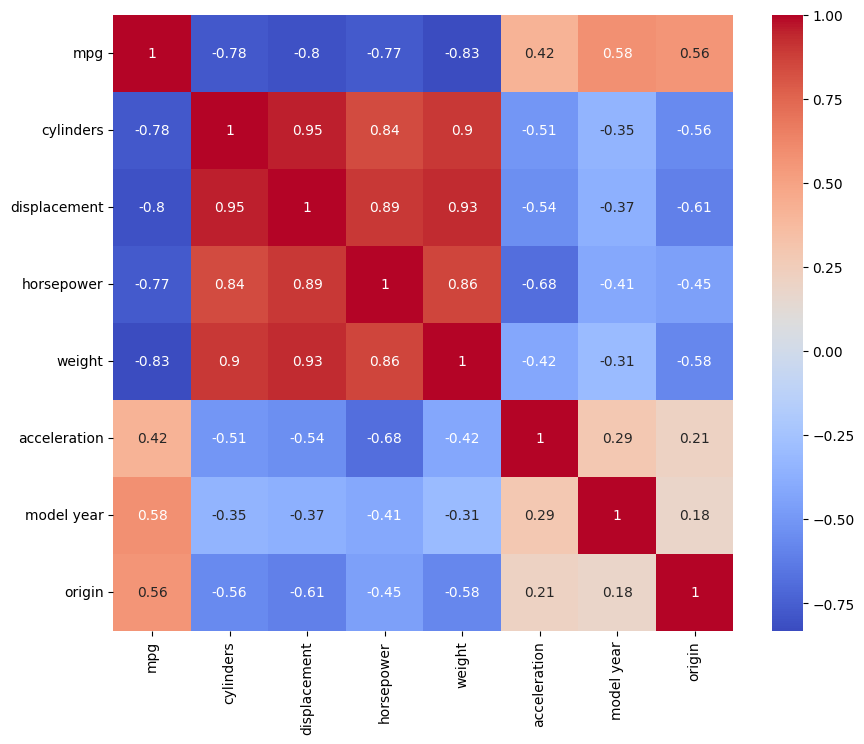

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

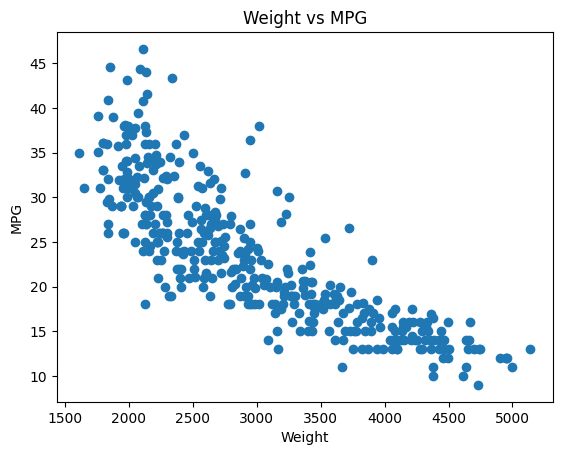

In [12]:
plt.scatter(df['weight'], df['mpg'])
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.title("Weight vs MPG")
plt.show()

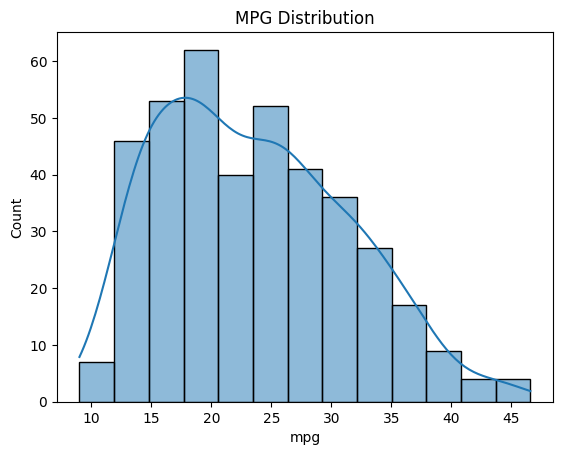

In [13]:
sns.histplot(df['mpg'], kde=True)
plt.title("MPG Distribution")
plt.show()

In [14]:
X = df.drop("mpg", axis=1)
y = df["mpg"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.linear_model import LinearRegression

model_simple = LinearRegression()
model_simple.fit(X_train[['weight']], y_train)

pred_simple = model_simple.predict(X_test[['weight']])

In [17]:
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

pred_multi = model_multi.predict(X_test)

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Simple Linear Regression Results:")
print("MAE:", mean_absolute_error(y_test, pred_simple))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_simple)))
print("R2 Score:", r2_score(y_test, pred_simple))

print("\nMultiple Linear Regression Results:")
print("MAE:", mean_absolute_error(y_test, pred_multi))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_multi)))
print("R2 Score:", r2_score(y_test, pred_multi))

Simple Linear Regression Results:
MAE: 3.1177861992064573
RMSE: 3.8593860994510765
R2 Score: 0.722971057303075

Multiple Linear Regression Results:
MAE: 2.253388405931761
RMSE: 2.86277000544469
R2 Score: 0.8475731044779433


In [19]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model_multi, X, y, cv=5, scoring='r2')
print("Cross Validation Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

Cross Validation Scores: [0.57146512 0.68566715 0.82348905 0.68191796 0.21527776]
Average CV Score: 0.5955634058641479
